# Bước 5: Thực Hiện Biến Đổi Dữ Liệu (Perform Data Transformation)

Biến đổi dữ liệu chuẩn bị cho phân tích và mô hình hóa.

**Mục tiêu:**
- Scaling/Normalizing biến số
- Encoding biến phân loại
- Biến đổi toán học (log, sqrt)
- Tạo biến dẫn xuất mới

## 5.1 Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Thư viện đã được import thành công!")

✅ Thư viện đã được import thành công!


## 5.2 Tải dữ liệu

In [2]:
try:
    df = pd.read_pickle('outputs/df_step4.pkl')
    print("✅ Đã tải dữ liệu từ Bước 4")
except:
    DATA_PATH = Path("../data/raw/accepted_2007_to_2018Q4.csv")
    df = pd.read_csv(DATA_PATH, nrows=50000, low_memory=False)
    print("📂 Đã tải dữ liệu gốc")

print(f"📊 Kích thước: {df.shape[0]:,} hàng × {df.shape[1]} cột")
original_cols = len(df.columns)

✅ Đã tải dữ liệu từ Bước 4
📊 Kích thước: 50,000 hàng × 111 cột


## 5.3 Encoding biến phân loại

In [3]:
print("=" * 70)
print("🏷️ ENCODING BIẾN PHÂN LOẠI")
print("=" * 70)

# Label Encoding cho biến thứ tự (ordinal)
if 'grade' in df.columns:
    le = LabelEncoder()
    df['grade_encoded'] = le.fit_transform(df['grade'].fillna('Unknown'))
    print(f"✅ grade: Label Encoded")
    print(f"   Mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

if 'sub_grade' in df.columns:
    le = LabelEncoder()
    df['sub_grade_encoded'] = le.fit_transform(df['sub_grade'].fillna('Unknown'))
    print(f"✅ sub_grade: Label Encoded")

# Custom encoding cho emp_length
if 'emp_length' in df.columns:
    emp_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8, '9 years': 9, '10+ years': 10
    }
    df['emp_length_encoded'] = df['emp_length'].map(emp_map)
    print(f"✅ emp_length: Custom Encoded (0-10)")

# Chuyển term sang số
if 'term' in df.columns:
    df['term_months'] = df['term'].str.extract(r'(\d+)').astype(float)
    print(f"✅ term: Extracted months (36/60)")

🏷️ ENCODING BIẾN PHÂN LOẠI
✅ grade: Label Encoded
   Mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
✅ sub_grade: Label Encoded
✅ emp_length: Custom Encoded (0-10)
✅ term: Extracted months (36/60)


In [4]:
# One-Hot Encoding cho biến nominal
print("\n--- One-Hot Encoding ---")

if 'home_ownership' in df.columns:
    dummies = pd.get_dummies(df['home_ownership'], prefix='home')
    df = pd.concat([df, dummies], axis=1)
    print(f"✅ home_ownership: {len(dummies.columns)} cột mới")

if 'verification_status' in df.columns:
    dummies = pd.get_dummies(df['verification_status'], prefix='verified')
    df = pd.concat([df, dummies], axis=1)
    print(f"✅ verification_status: {len(dummies.columns)} cột mới")

if 'purpose' in df.columns:
    dummies = pd.get_dummies(df['purpose'], prefix='purpose')
    df = pd.concat([df, dummies], axis=1)
    print(f"✅ purpose: {len(dummies.columns)} cột mới")


--- One-Hot Encoding ---


✅ home_ownership: 4 cột mới
✅ verification_status: 3 cột mới


✅ purpose: 12 cột mới


## 5.4 Biến đổi toán học (Log Transform)

In [5]:
print("=" * 70)
print("📈 BIẾN ĐỔI TOÁN HỌC (LOG TRANSFORM)")
print("=" * 70)

# Các biến thường có phân bố lệch cần log transform
skewed_cols = ['annual_inc', 'revol_bal', 'loan_amnt', 'tot_cur_bal']
skewed_cols = [col for col in skewed_cols if col in df.columns]

for col in skewed_cols:
    skew_before = df[col].skew()
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
    skew_after = df[f'{col}_log'].skew()
    print(f"✅ {col}: skew {skew_before:.2f} → {skew_after:.2f}")

📈 BIẾN ĐỔI TOÁN HỌC (LOG TRANSFORM)
✅ annual_inc: skew 52.71 → 0.07
✅ revol_bal: skew 8.28 → -2.16
✅ loan_amnt: skew 0.61 → -0.80
✅ tot_cur_bal: skew 2.97 → -0.57


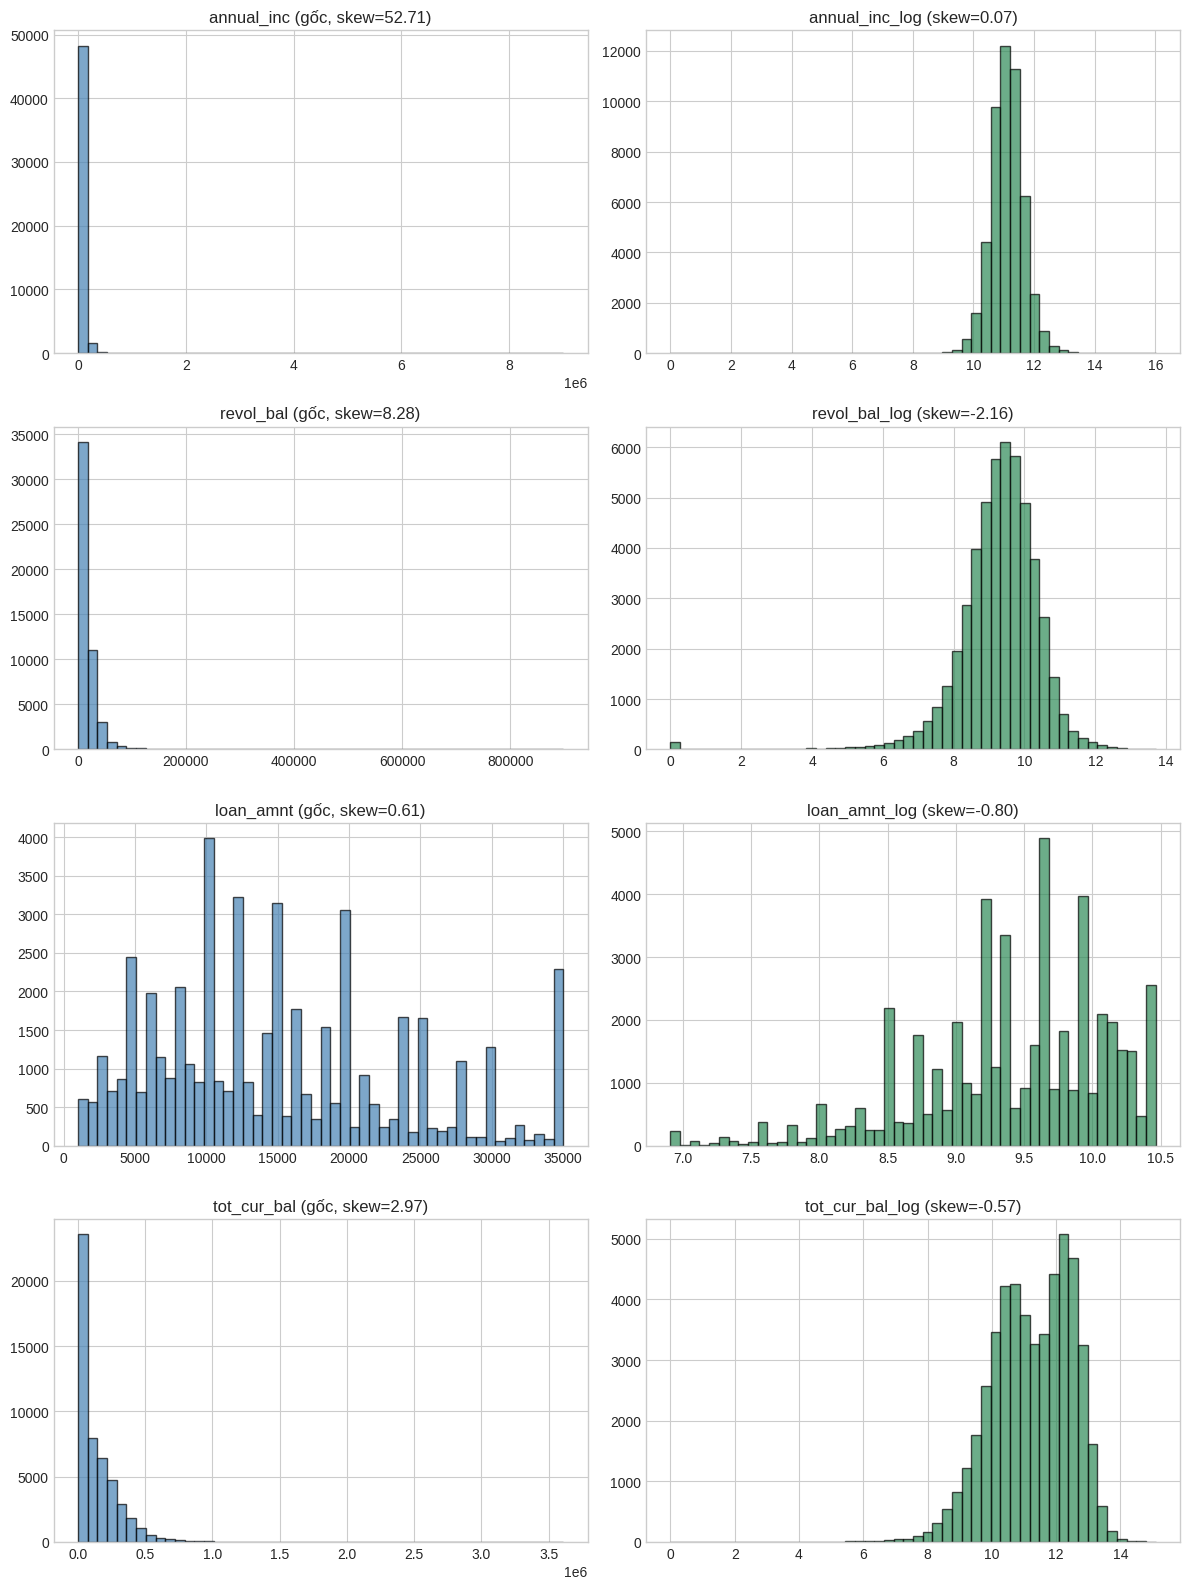

In [6]:
# Visualize trước và sau log transform
if len(skewed_cols) > 0:
    fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(12, 4*len(skewed_cols)))
    
    for i, col in enumerate(skewed_cols):
        # Trước
        ax1 = axes[i, 0] if len(skewed_cols) > 1 else axes[0]
        data = df[col].dropna()
        ax1.hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        ax1.set_title(f'{col} (gốc, skew={data.skew():.2f})')
        
        # Sau
        ax2 = axes[i, 1] if len(skewed_cols) > 1 else axes[1]
        log_data = df[f'{col}_log'].dropna()
        ax2.hist(log_data, bins=50, edgecolor='black', alpha=0.7, color='seagreen')
        ax2.set_title(f'{col}_log (skew={log_data.skew():.2f})')
    
    plt.tight_layout()
    plt.savefig('outputs/05_log_transform.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5.5 Scaling/Normalizing

In [7]:
print("=" * 70)
print("📏 SCALING VÀ NORMALIZING")
print("=" * 70)

# Chọn biến số để scale
num_cols_to_scale = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti']
num_cols_to_scale = [col for col in num_cols_to_scale if col in df.columns]

# StandardScaler (z-score)
scaler_std = StandardScaler()
for col in num_cols_to_scale:
    df[f'{col}_scaled'] = scaler_std.fit_transform(df[[col]].fillna(0))
    print(f"✅ {col}_scaled: mean=0, std=1")

# MinMaxScaler (0-1)
scaler_mm = MinMaxScaler()
for col in num_cols_to_scale:
    df[f'{col}_norm'] = scaler_mm.fit_transform(df[[col]].fillna(0))
    print(f"✅ {col}_norm: range [0, 1]")

📏 SCALING VÀ NORMALIZING
✅ loan_amnt_scaled: mean=0, std=1
✅ int_rate_scaled: mean=0, std=1
✅ installment_scaled: mean=0, std=1
✅ annual_inc_scaled: mean=0, std=1
✅ dti_scaled: mean=0, std=1
✅ loan_amnt_norm: range [0, 1]
✅ int_rate_norm: range [0, 1]
✅ installment_norm: range [0, 1]
✅ annual_inc_norm: range [0, 1]
✅ dti_norm: range [0, 1]


## 5.6 Tạo biến dẫn xuất mới

In [8]:
print("=" * 70)
print("🔧 TẠO BIẾN DẪN XUẤT MỚI")
print("=" * 70)

# Tỷ lệ khoản vay trên thu nhập
if 'loan_amnt' in df.columns and 'annual_inc' in df.columns:
    df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
    print("✅ loan_to_income = loan_amnt / annual_inc")

# Tỷ lệ trả góp trên thu nhập
if 'installment' in df.columns and 'annual_inc' in df.columns:
    df['installment_to_income'] = df['installment'] * 12 / (df['annual_inc'] + 1)
    print("✅ installment_to_income = (installment * 12) / annual_inc")

# Tổng lãi ước tính
if 'loan_amnt' in df.columns and 'int_rate' in df.columns:
    df['total_interest_est'] = df['loan_amnt'] * df['int_rate'] / 100
    print("✅ total_interest_est = loan_amnt * int_rate / 100")

# Tỷ lệ tài khoản đang mở
if 'open_acc' in df.columns and 'total_acc' in df.columns:
    df['open_acc_ratio'] = df['open_acc'] / (df['total_acc'] + 1)
    print("✅ open_acc_ratio = open_acc / total_acc")

🔧 TẠO BIẾN DẪN XUẤT MỚI
✅ loan_to_income = loan_amnt / annual_inc
✅ installment_to_income = (installment * 12) / annual_inc
✅ total_interest_est = loan_amnt * int_rate / 100
✅ open_acc_ratio = open_acc / total_acc


In [9]:
# Tạo biến tương tác
print("\n--- Biến tương tác ---")

if 'int_rate' in df.columns and 'dti' in df.columns:
    df['int_rate_x_dti'] = df['int_rate'] * df['dti']
    print("✅ int_rate_x_dti = int_rate * dti")

if 'loan_amnt' in df.columns and 'int_rate' in df.columns:
    df['loan_x_rate'] = df['loan_amnt'] * df['int_rate'] / 100
    print("✅ loan_x_rate = loan_amnt * int_rate / 100")


--- Biến tương tác ---
✅ int_rate_x_dti = int_rate * dti
✅ loan_x_rate = loan_amnt * int_rate / 100


## 5.7 Tạo biến mục tiêu nhị phân

In [10]:
if 'loan_status' in df.columns:
    print("=" * 70)
    print("🎯 TẠO BIẾN MỤC TIÊU NHỊ PHÂN")
    print("=" * 70)
    
    # Định nghĩa khoản vay xấu
    bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 
                    'Late (16-30 days)', 
                    'Does not meet the credit policy. Status:Charged Off']
    
    df['is_bad_loan'] = df['loan_status'].isin(bad_statuses).astype(int)
    
    print(f"Khoản vay tốt (0): {(df['is_bad_loan'] == 0).sum():,}")
    print(f"Khoản vay xấu (1): {(df['is_bad_loan'] == 1).sum():,}")
    print(f"Tỷ lệ xấu: {df['is_bad_loan'].mean()*100:.2f}%")

🎯 TẠO BIẾN MỤC TIÊU NHỊ PHÂN
Khoản vay tốt (0): 40,688
Khoản vay xấu (1): 9,312
Tỷ lệ xấu: 18.62%


## 5.8 Tổng hợp các biến mới

In [11]:
print("=" * 70)
print("📋 TỔNG HỢP CÁC BIẾN MỚI")
print("=" * 70)

new_cols = len(df.columns) - original_cols
new_features = df.columns[original_cols:].tolist()

print(f"\nSố cột ban đầu: {original_cols}")
print(f"Số cột mới: {new_cols}")
print(f"Tổng số cột: {len(df.columns)}")

print(f"\nDanh sách {len(new_features)} biến mới:")
for i, feat in enumerate(new_features, 1):
    print(f"  {i:2d}. {feat}")

📋 TỔNG HỢP CÁC BIẾN MỚI

Số cột ban đầu: 111
Số cột mới: 44
Tổng số cột: 155

Danh sách 44 biến mới:
   1. grade_encoded
   2. sub_grade_encoded
   3. emp_length_encoded
   4. term_months
   5. home_ANY
   6. home_MORTGAGE
   7. home_OWN
   8. home_RENT
   9. verified_Not Verified
  10. verified_Source Verified
  11. verified_Verified
  12. purpose_car
  13. purpose_credit_card
  14. purpose_debt_consolidation
  15. purpose_home_improvement
  16. purpose_house
  17. purpose_major_purchase
  18. purpose_medical
  19. purpose_moving
  20. purpose_other
  21. purpose_renewable_energy
  22. purpose_small_business
  23. purpose_vacation
  24. annual_inc_log
  25. revol_bal_log
  26. loan_amnt_log
  27. tot_cur_bal_log
  28. loan_amnt_scaled
  29. int_rate_scaled
  30. installment_scaled
  31. annual_inc_scaled
  32. dti_scaled
  33. loan_amnt_norm
  34. int_rate_norm
  35. installment_norm
  36. annual_inc_norm
  37. dti_norm
  38. loan_to_income
  39. installment_to_income
  40. total_inte

## 5.9 Tổng kết Bước 5

In [12]:
print("=" * 70)
print("📋 TỔNG KẾT BƯỚC 5: BIẾN ĐỔI DỮ LIỆU")
print("=" * 70)
print(f"""
✅ ĐÃ HOÀN THÀNH:
   • Label Encoding: grade, sub_grade, emp_length
   • One-Hot Encoding: home_ownership, verification_status, purpose
   • Log Transform: {len(skewed_cols)} biến
   • Scaling: {len(num_cols_to_scale)} biến (StandardScaler + MinMaxScaler)
   • Biến dẫn xuất: loan_to_income, installment_to_income, etc.
   • Biến mục tiêu: is_bad_loan (binary)

📊 KẾT QUẢ:
   • Cột ban đầu: {original_cols}
   • Cột mới: {new_cols}
   • Tổng cột: {len(df.columns)}

📝 BƯỚC TIẾP THEO:
   → Bước 6: Trực quan hóa mối quan hệ dữ liệu
""")

# Lưu dataframe
df.to_pickle('outputs/df_step5.pkl')
print("\n💾 Đã lưu: outputs/df_step5.pkl")

📋 TỔNG KẾT BƯỚC 5: BIẾN ĐỔI DỮ LIỆU

✅ ĐÃ HOÀN THÀNH:
   • Label Encoding: grade, sub_grade, emp_length
   • One-Hot Encoding: home_ownership, verification_status, purpose
   • Log Transform: 4 biến
   • Scaling: 5 biến (StandardScaler + MinMaxScaler)
   • Biến dẫn xuất: loan_to_income, installment_to_income, etc.
   • Biến mục tiêu: is_bad_loan (binary)

📊 KẾT QUẢ:
   • Cột ban đầu: 111
   • Cột mới: 44
   • Tổng cột: 155

📝 BƯỚC TIẾP THEO:
   → Bước 6: Trực quan hóa mối quan hệ dữ liệu


💾 Đã lưu: outputs/df_step5.pkl
